data used for analysis:
https://drive.google.com/drive/folders/1l61uv4i9CLb6jW4g_UCV6rZw6hyxcNMa?usp=sharing

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta


# Open the GRIB file
ds = xr.open_dataset("../../../data/spring_2025_data/soil_moisture_data/test.grib", engine="cfgrib")

print(ds)

<xarray.Dataset>
Dimensions:              (time: 84, latitude: 1801, longitude: 3600)
Coordinates:
    number               int64 ...
  * time                 (time) datetime64[ns] 2017-01-01 ... 2023-12-01
    step                 timedelta64[ns] ...
    depthBelowLandLayer  float64 ...
  * latitude             (latitude) float64 90.0 89.9 89.8 ... -89.8 -89.9 -90.0
  * longitude            (longitude) float64 0.0 0.1 0.2 ... 359.7 359.8 359.9
    valid_time           (time) datetime64[ns] ...
Data variables:
    swvl1                (time, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-21T22:48 GRIB to CDM+CF via cfgrib-0.9.1...


# EDA for the soil moisture data

## Initial Observations

In [2]:
# List variables
print(ds.variables)

# Check coordinates (e.g., time, latitude, longitude)
print(ds.coords)

# Check the data's attribute
print(ds['swvl1'].attrs)

Frozen({'number': <xarray.Variable ()>
[1 values with dtype=int64]
Attributes:
    long_name:      ensemble member numerical id
    units:          1
    standard_name:  realization, 'time': <xarray.IndexVariable 'time' (time: 84)>
array(['2017-01-01T00:00:00.000000000', '2017-02-01T00:00:00.000000000',
       '2017-03-01T00:00:00.000000000', '2017-04-01T00:00:00.000000000',
       '2017-05-01T00:00:00.000000000', '2017-06-01T00:00:00.000000000',
       '2017-07-01T00:00:00.000000000', '2017-08-01T00:00:00.000000000',
       '2017-09-01T00:00:00.000000000', '2017-10-01T00:00:00.000000000',
       '2017-11-01T00:00:00.000000000', '2017-12-01T00:00:00.000000000',
       '2018-01-01T00:00:00.000000000', '2018-02-01T00:00:00.000000000',
       '2018-03-01T00:00:00.000000000', '2018-04-01T00:00:00.000000000',
       '2018-05-01T00:00:00.000000000', '2018-06-01T00:00:00.000000000',
       '2018-07-01T00:00:00.000000000', '2018-08-01T00:00:00.000000000',
       '2018-09-01T00:00:00.000000000'

This dataset gives you global, high-resolution (0.1°) soil moisture values in the top ~7 cm of soil.

The values are monthly averages, from a climate analysis model.

Each value represents the average for one grid cell ~11 km × 11 km in size.

This is suitable for regional analysis, not exact locations of single trees.

## Data Cleaning

In [3]:
times = ds['time'].values         # Array of datetime objects
lats = ds['latitude'].values      # Array of latitude points
lons = ds['longitude'].values     # Array of longitude points

soil = ds['swvl1']                # Shape: (time, lat, lon)
value = soil[0, 1000, 2000].item()  # Example: soil moisture at one point

### Slice the climate data to only Kerela

In [49]:
kerala = ds['swvl1'].sel(
    latitude=slice(12.5, 8.0),
    longitude=slice(74.5, 77.5)
)

#computes the average soil moisture across the entire Kerala region for each time step
kerala_avg = kerala.mean(dim=["latitude", "longitude"]) 

kerala_avg

<xarray.DataArray 'swvl1' (time: 84)>
array([0.23748772, 0.22419575, 0.29519683, 0.300218  , 0.36557558,
       0.40333137, 0.38063496, 0.40838066, 0.4265056 , 0.41193798,
       0.38685137, 0.32927996, 0.22199506, 0.2335389 , 0.26137194,
       0.31111732, 0.3935812 , 0.41637233, 0.41095585, 0.40245175,
       0.35150984, 0.41162896, 0.38033196, 0.33063307, 0.22935036,
       0.226879  , 0.21811344, 0.29062146, 0.337368  , 0.38242203,
       0.39733005, 0.42202207, 0.41495678, 0.43261084, 0.41297933,
       0.36357877, 0.24261679, 0.20171939, 0.24220845, 0.27861837,
       0.3365037 , 0.3967534 , 0.42291173, 0.40596765, 0.43255982,
       0.39565757, 0.38046187, 0.36918116, 0.3671326 , 0.23941876,
       0.22576877, 0.3245022 , 0.39284888, 0.39650783, 0.41715512,
       0.40431562, 0.40434426, 0.43606842, 0.44054556, 0.34461507,
       0.23487914, 0.21938181, 0.23264433, 0.33844116, 0.3948605 ,
       0.39747363, 0.4286223 , 0.42169678, 0.39721882, 0.3991141 ,
       0.39962265, 0.36943448, 0.2446438 , 0.22618778, 0.23076025,
       0.27300236, 0.37966737, 0.37834868, 0.41758043, 0.34026304,
       0.40956828, 0.39748147, 0.41132554, 0.36333293], dtype=float32)
Coordinates:
    number               int64 ...
  * time                 (time) datetime64[ns] 2017-01-01 ... 2023-12-01
    step                 timedelta64[ns] ...
    depthBelowLandLayer  float64 ...
    valid_time           (time) datetime64[ns] ...

In [55]:
valid_kerala = kerala.dropna(dim="latitude", how="all")
valid_kerala = valid_kerala.dropna(dim="longitude", how="all")

valid_kerala

<xarray.DataArray 'swvl1' (time: 84, latitude: 44, longitude: 25)>
array([[[0.194092, 0.28476 , ..., 0.140366, 0.133911],
        [     nan, 0.175064, ..., 0.133194, 0.165878],
        ...,
        [     nan,      nan, ..., 0.104431, 0.106277],
        [     nan,      nan, ..., 0.075867, 0.082291]],

       [[0.196075, 0.284775, ..., 0.124008, 0.115814],
        [     nan, 0.178253, ..., 0.117645, 0.150406],
        ...,
        [     nan,      nan, ..., 0.090027, 0.090271],
        [     nan,      nan, ..., 0.060394, 0.065323]],

       ...,

       [[0.365433, 0.427673, ..., 0.3134  , 0.333176],
        [     nan, 0.342773, ..., 0.299576, 0.348694],
        ...,
        [     nan,      nan, ..., 0.316559, 0.315399],
        [     nan,      nan, ..., 0.285599, 0.288773]],

       [[0.286667, 0.373322, ..., 0.197266, 0.230042],
        [     nan, 0.255676, ..., 0.182785, 0.26384 ],
        ...,
        [     nan,      nan, ..., 0.261307, 0.256668],
        [     nan,      nan, ..., 0.226761, 0.233276]]], dtype=float32)
Coordinates:
    number               int64 ...
  * time                 (time) datetime64[ns] 2017-01-01 ... 2023-12-01
    step                 timedelta64[ns] ...
    depthBelowLandLayer  float64 ...
  * latitude             (latitude) float64 12.4 12.3 12.2 12.1 ... 8.3 8.2 8.1
  * longitude            (longitude) float64 75.1 75.2 75.3 ... 77.3 77.4 77.5
    valid_time           (time) datetime64[ns] ...
Attributes: (12/31)
    GRIB_paramId:                             39
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      6483600
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           swvl1
    GRIB_totalNumber:                         0
    GRIB_units:                               m**3 m**-3
    long_name:                                Volumetric soil water layer 1
    units:                                    m**3 m**-3
    standard_name:                            unknown

In [53]:
_, lat_count, lon_count = kerala.shape
total_grid_cells = lat_count * lon_count
print(f"Total grid cells over Kerala: {total_grid_cells}")

Total grid cells over Kerala: 1395


## Visualizations on soil moisture at Kerela

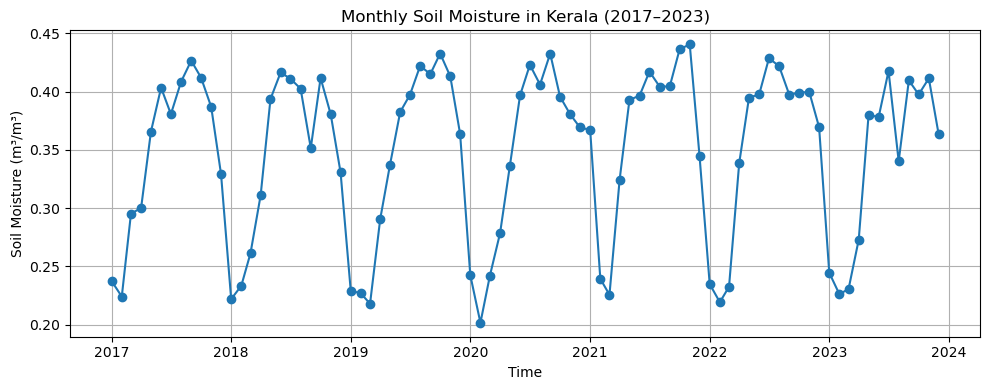

In [11]:
kerala_avg_df = kerala_avg.to_series().reset_index()
kerala_avg_df['month'] = kerala_avg_df['time'].dt.to_period('M')


plt.figure(figsize=(10, 4))
plt.plot(kerala_avg_df['time'], kerala_avg_df['swvl1'], marker='o')
plt.title("Monthly Soil Moisture in Kerala (2017–2023)")
plt.xlabel("Time")
plt.ylabel("Soil Moisture (m³/m³)")
plt.grid(True)
plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

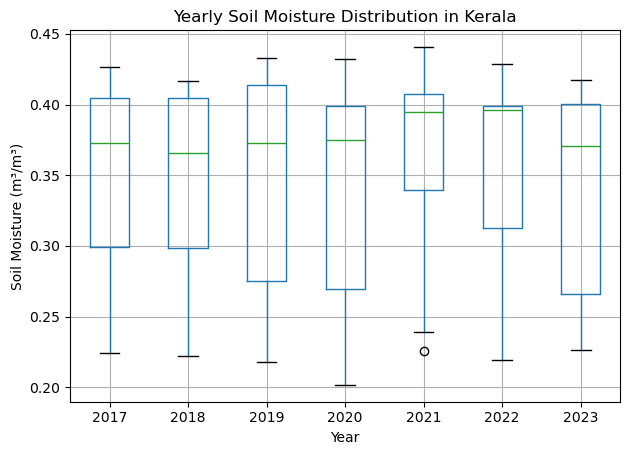

In [12]:
kerala_avg_df['year'] = kerala_avg_df['time'].dt.year

plt.figure(figsize=(8, 4))
kerala_avg_df.boxplot(column='swvl1', by='year')
plt.title("Yearly Soil Moisture Distribution in Kerala")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Soil Moisture (m³/m³)")
plt.grid(True)
plt.tight_layout()
plt.show()


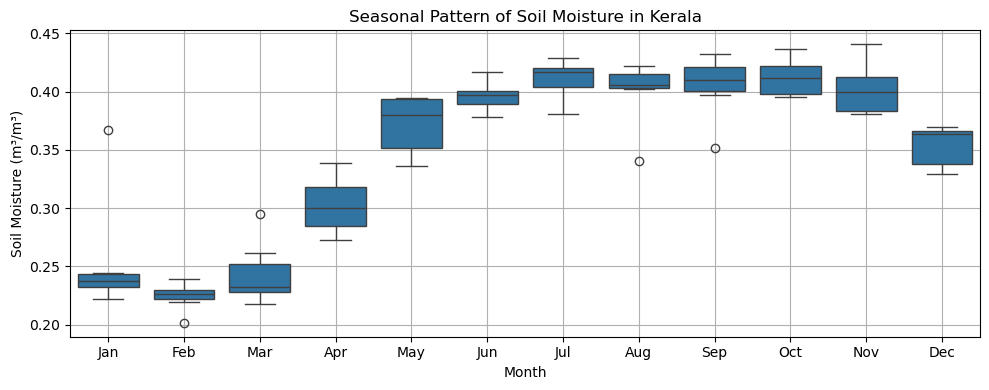

In [13]:
kerala_avg_df['month_name'] = kerala_avg_df['time'].dt.strftime('%b')

import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x='month_name', y='swvl1', data=kerala_avg_df,
            order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title("Seasonal Pattern of Soil Moisture in Kerala")
plt.xlabel("Month")
plt.ylabel("Soil Moisture (m³/m³)")
plt.grid(True)
plt.tight_layout()
plt.show()


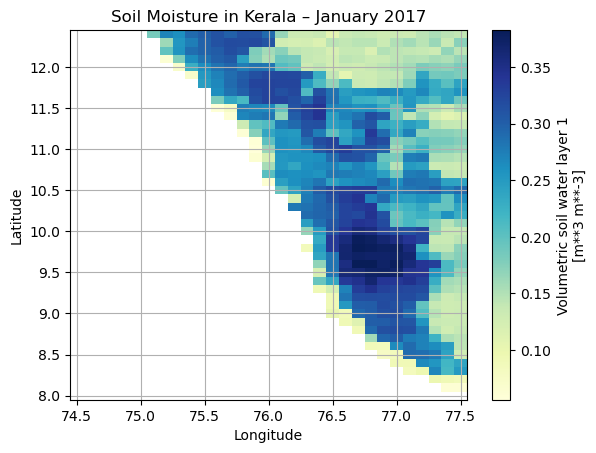

In [91]:
import matplotlib.pyplot as plt

# Pick a specific time index, e.g., January 2017
kerala_slice = kerala.sel(time='2018-02-01')

# Plot it
kerala_slice.plot(cmap='YlGnBu')
plt.title("Soil Moisture in Kerala – January 2017")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


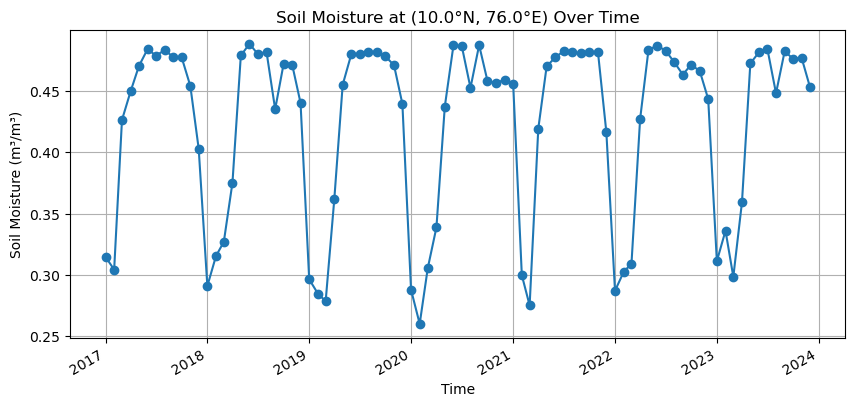

In [92]:
# Pick a sample grid point
sample_point = kerala.sel(latitude=10.0, longitude=77.0, method='nearest')

# Plot time series
plt.figure(figsize=(10, 4))
sample_point.plot(marker='o')
plt.title("Soil Moisture at (10.0°N, 76.0°E) Over Time")
plt.xlabel("Time")
plt.ylabel("Soil Moisture (m³/m³)")
plt.grid(True)
plt.show()

## Export a csv file

In [88]:
# Load GRIB file
ds = xr.open_dataset("test.grib", engine="cfgrib")
soil = ds['swvl1']

# Select Kerala region (adjusted to avoid ocean-heavy edges if needed)
kerala = soil.sel(latitude=slice(12.5, 8.0), longitude=slice(74.5, 77.5))

# Convert to DataFrame with all time steps (will duplicate lat/lon)
df = kerala.to_dataframe().reset_index()

# Drop duplicate lat/lon combinations and assign grid IDs
grid_df = df[['latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
grid_df['grid_id'] = range(len(grid_df))

# Reorder columns
grid_df = grid_df[['grid_id', 'latitude', 'longitude']]

# Print the result
print(grid_df)


      grid_id  latitude  longitude
0           0      12.4       74.5
1           1      12.4       74.6
2           2      12.4       74.7
3           3      12.4       74.8
4           4      12.4       74.9
...       ...       ...        ...
1390     1390       8.0       77.1
1391     1391       8.0       77.2
1392     1392       8.0       77.3
1393     1393       8.0       77.4
1394     1394       8.0       77.5

[1395 rows x 3 columns]


In [ ]:
# Select just January 2017
jan_2017 = kerala.sel(time='2017-01-01')

# Convert to DataFrame
jan_df = jan_2017.to_dataframe().reset_index()

# Drop NaNs (likely ocean or invalid points)
jan_df = jan_df.dropna(subset=['swvl1'])

# Merge with grid_id table to include IDs
jan_merged = pd.merge(jan_df, grid_df, on=['latitude', 'longitude'], how='inner')

date_col = '1_1_2017'
jan_result = jan_merged[['grid_id', 'latitude', 'longitude', 'swvl1']].rename(columns={'swvl1': date_col})

# Export to CSV
jan_result.to_csv("../../../data/spring_2025_data/soil_moisture_data/soil_moisture_jan_2017.csv", index=False)

# Optional: preview result
print(jan_result.head())


   grid_id  latitude  longitude  1_1_2017
0        6      12.4       75.1  0.194092
1        7      12.4       75.2  0.284760
2        8      12.4       75.3  0.279510
3        9      12.4       75.4  0.309128
4       10      12.4       75.5  0.310059


In [ ]:
final_df = grid_df.copy()

for month in range(1, 13):
    date_str = f"2017-{month:02d}-01"      # format: 2017-01-01, etc.
    col_name = f"{month}_1_2017"           # column header like 1_1_2017

    # Extract monthly data
    try:
        month_data = kerala.sel(time=date_str).to_dataframe().reset_index()
        month_data = month_data.dropna(subset=['swvl1'])

        # Merge with grid_id
        merged = pd.merge(month_data, grid_df, on=['latitude', 'longitude'], how='inner')
        # merged = merged[['grid_id', col_name]].rename(columns={'swvl1': col_name})
        merged = merged.rename(columns={'swvl1': col_name})  # Rename first
        merged = merged[['grid_id', col_name]]               # Then select final columns
        # print("Columns in merged before rename:", merged.columns.tolist())

        # Add to final dataframe
        final_df = pd.merge(final_df, merged, on='grid_id', how='left')
        # print(f"✅ Added data for {date_str} — matched {len(merged)} rows.")

    except KeyError:
        print(f"Date {date_str} not found in dataset. Skipping.")


monthly_cols = [f"{m}_1_2017" for m in range(1, 13)]
final_df = final_df.dropna(subset=monthly_cols, how='all')

# Export to CSV
final_df.to_csv("../../../data/spring_2025_data/soil_moisture_data/soil_moisture_kerala.csv", index=False)

# Optional: preview
print(final_df.head())


    grid_id  latitude  longitude  1_1_2017  2_1_2017  3_1_2017  4_1_2017  \
6         6      12.4       75.1  0.194092  0.196075  0.199356  0.272369   
7         7      12.4       75.2  0.284760  0.284775  0.308807  0.389771   
8         8      12.4       75.3  0.279510  0.276703  0.321579  0.409515   
9         9      12.4       75.4  0.309128  0.305466  0.344742  0.444748   
10       10      12.4       75.5  0.310059  0.308319  0.351746  0.456070   

    5_1_2017  6_1_2017  7_1_2017  8_1_2017  9_1_2017  10_1_2017  11_1_2017  \
6   0.361328  0.432587  0.428833  0.427872  0.417480   0.399002   0.326828   
7   0.454666  0.486862  0.487701  0.483444  0.485748   0.469940   0.430405   
8   0.463333  0.484985  0.484009  0.481888  0.484711   0.470367   0.441269   
9   0.466843  0.482422  0.483307  0.481064  0.480179   0.472015   0.448318   
10  0.474045  0.486343  0.485367  0.481628  0.480240   0.473801   0.441895   

    12_1_2017  
6    0.243286  
7    0.341934  
8    0.351654  
9    0.372

In [ ]:
final_df = grid_df.copy()

for year in range(2017, 2024):  # 2024 is exclusive
    for month in range(1, 13):
        date_str = f"{year}-{month:02d}-01"     # e.g., 2017-01-01
        col_name = f"{month}_1_{year}"          # e.g., 1_1_2017

        try:
            # Select soil moisture for this month
            month_data = kerala.sel(time=np.datetime64(date_str)).to_dataframe().reset_index()
            month_data = month_data.dropna(subset=['swvl1'])

            # Round to avoid float mismatches
            month_data['latitude'] = month_data['latitude'].round(4)
            month_data['longitude'] = month_data['longitude'].round(4)
            grid_df['latitude'] = grid_df['latitude'].round(4)
            grid_df['longitude'] = grid_df['longitude'].round(4)

            # Merge to attach grid_id
            merged = pd.merge(month_data, grid_df, on=['latitude', 'longitude'], how='inner')
            merged = merged.rename(columns={'swvl1': col_name})
            merged = merged[['grid_id', col_name]]

            # Add to final dataframe
            final_df = pd.merge(final_df, merged, on='grid_id', how='left')
            # print(f"✅ Processed {col_name}")

        except KeyError:
            print(f"❌ Date {date_str} not found in dataset. Skipping.")


# Drop rows where all months are missing (i.e., ocean grids)
all_months = [f"{m}_1_{y}" for y in range(2017, 2024) for m in range(1, 13)]
final_df = final_df.dropna(subset=all_months, how='all')

# Export to CSV
final_df.to_csv("../../../data/spring_2025_data/soil_moisture_data/soil_moisture_kerala_2017_2023.csv", index=False)

# Optional: preview
print(final_df.head())



    grid_id  latitude  longitude  1_1_2017  2_1_2017  3_1_2017  4_1_2017  \
6         6      12.4       75.1  0.194092  0.196075  0.199356  0.272369   
7         7      12.4       75.2  0.284760  0.284775  0.308807  0.389771   
8         8      12.4       75.3  0.279510  0.276703  0.321579  0.409515   
9         9      12.4       75.4  0.309128  0.305466  0.344742  0.444748   
10       10      12.4       75.5  0.310059  0.308319  0.351746  0.456070   

    5_1_2017  6_1_2017  7_1_2017  ...  3_1_2023  4_1_2023  5_1_2023  6_1_2023  \
6   0.361328  0.432587  0.428833  ...  0.187210  0.199356  0.318298  0.421097   
7   0.454666  0.486862  0.487701  ...  0.270660  0.294525  0.419815  0.484406   
8   0.463333  0.484985  0.484009  ...  0.260178  0.300705  0.435944  0.481018   
9   0.466843  0.482422  0.483307  ...  0.289246  0.337601  0.453598  0.481857   
10  0.474045  0.486343  0.485367  ...  0.293167  0.339508  0.462143  0.483154   

    7_1_2023  8_1_2023  9_1_2023  10_1_2023  11_1_2023  

# Combining new data with pre-existing cleaned citizen submitted data

## Example plant: Mango

In [9]:
obs_df = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/cleaned_alldata_version2.csv")
soil_df = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/soil_moisture_kerala_2017_2023.csv")

# Round for matching
obs_df['Lat'] = obs_df['Lat'].round(4)
obs_df['Long'] = obs_df['Long'].round(4)
soil_df['latitude'] = soil_df['latitude'].round(4)
soil_df['longitude'] = soil_df['longitude'].round(4)

# Filter mango observations
mango_df = obs_df[obs_df['Species_name'].str.contains("Mango", case=False, na=False)].copy()

# Try parsing the original date
mango_df['date'] = pd.to_datetime(mango_df['Date_of_observation'], errors='coerce')

# Fill missing dates from year + week (assumes Week 1 starts Jan 1)
def fill_date(row):
    if pd.isnull(row['date']) and not pd.isnull(row.get('Year')) and not pd.isnull(row.get('Week')):
        try:
            base = datetime(int(row['Year']), 1, 1)
            return base + timedelta(weeks=int(row['Week']))
        except:
            return pd.NaT
    return row['date']

mango_df['date'] = mango_df.apply(fill_date, axis=1)
mango_df = mango_df[
    (mango_df['date'].dt.year >= 2017) & 
    (mango_df['date'].dt.year <= 2023)
]

# Create month/year columns
mango_df = mango_df.dropna(subset=['date'])
mango_df['month'] = mango_df['date'].dt.month.astype(int)
mango_df['year'] = mango_df['date'].dt.year.astype(int)
mango_df['moisture_col'] = mango_df['month'].astype(str) + "_1_" + mango_df['year'].astype(str)

# Assign grid_id
def find_nearest_grid(lat, lon, grid_data):
    dists = np.abs(grid_data['latitude'] - lat) + np.abs(grid_data['longitude'] - lon)
    idx = dists.idxmin()
    return grid_data.loc[idx, 'grid_id']

mango_df['grid_id'] = mango_df.apply(
    lambda row: find_nearest_grid(row['Lat'], row['Long'], soil_df), axis=1
)

# Get soil moisture, or a message if moisture_col doesn't exist
def get_moisture(row):
    col = row['moisture_col']
    if col in soil_df.columns:
        match = soil_df.loc[soil_df['grid_id'] == row['grid_id'], col]
        return match.values[0] if not match.empty else "no data"
    return "no dates specified"

mango_df['soil_moisture'] = mango_df.apply(get_moisture, axis=1)

print(mango_df.head())

# Final columns only
final_output = mango_df[['Species_name', 'Date_of_observation','Leaves_fresh', 'Leaves_mature', 'Leaves_old', 'Flowers_bud', 'Flowers_open', 'Fruits_unripe', 'Fruits_ripe', 'Fruits_open', 'Lat', 'Long', 'grid_id', 'soil_moisture']]

# Export
final_output.to_csv("../../../data/spring_2025_data/soil_moisture_data/mango_soil_moisture_output.csv", index=False)
print(final_output.head())


    Unnamed: 0 Date_of_observation                            Species_name  \
6            7          2020-01-01  Mango (all varieties)-Mangifera indica   
7            8          2020-01-01  Mango (all varieties)-Mangifera indica   
10          11          2020-01-01  Mango (all varieties)-Mangifera indica   
15          16          2020-01-01  Mango (all varieties)-Mangifera indica   
16          17          2020-01-01  Mango (all varieties)-Mangifera indica   

        Lat     Long State_name  Leaves_fresh  Leaves_mature  Leaves_old  \
6   12.1212  75.2171     Kerala           1.0            2.0         1.0   
7   12.1212  75.2171     Kerala           1.0            2.0         0.0   
10  12.1212  75.2171     Kerala           1.0            1.0         0.0   
15  10.9987  75.9918     Kerala           1.0            2.0         1.0   
16  10.9313  76.4188     Kerala           2.0            1.0         1.0   

    Flowers_bud  ...  Fruits_open    Year  Week  Species_id       date  mo

# Initial Analysis

In [48]:
# Load merged mango + soil moisture + phenophase data
merged = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/mango_soil_moisture_output.csv") 

# Drop unwanted phenophase columns
merged = merged.drop(columns=['Flowers_male', 'Flowers_Female', 'Leaves_old', 'Fruits_open'], errors='ignore')

# Parse and extract date info
merged['date'] = pd.to_datetime(merged['Date_of_observation'], errors='coerce')
merged = merged.dropna(subset=['date'])
merged['year'] = merged['date'].dt.year
merged['month'] = merged['date'].dt.month

# Define phenophases to include
phenos = ['Flowers_bud', 'Flowers_open', 'Fruits_unripe', 'Fruits_ripe', 
          'Leaves_fresh', 'Leaves_mature']

# Start summary with average soil moisture per (year, month)
summary = merged.groupby(['year', 'month']).agg(
    avg_soil_moisture=('soil_moisture', 'mean')
).reset_index()

# Compute % presence for each phenophase
for p in phenos:
    valid = merged[merged[p].isin([0, 1, 2])].copy()
    valid[f'{p}_present'] = valid[p] >= 1  # 1 or 2 means present
    presence = valid.groupby(['year', 'month'])[f'{p}_present'].mean().reset_index(name=f'{p}_pct')
    summary = pd.merge(summary, presence, on=['year', 'month'], how='left')

# Output
print(summary.head())
summary.to_csv("../../../data/spring_2025_data/soil_moisture_data/mango_phenophase_soilmoisture_summary.csv", index=False)


   year  month  avg_soil_moisture  Flowers_bud_pct  Flowers_open_pct  \
0  2017      1           0.261556         0.360000          0.325893   
1  2017      2           0.219704         0.442231          0.426295   
2  2017      3           0.321370         0.376812          0.364078   
3  2017      4           0.359080         0.438356          0.365297   
4  2017      5           0.406679         0.282407          0.265116   

   Fruits_unripe_pct  Fruits_ripe_pct  Leaves_fresh_pct  Leaves_mature_pct  
0           0.275556         0.253333          0.753363           0.866667  
1           0.380000         0.248000          0.713147           0.964000  
2           0.387560         0.342995          0.784689           0.942584  
3           0.263636         0.154545          0.778281           0.936937  
4           0.230415         0.165138          0.770642           0.963303  


Filters only 2017 data

Finds the top 3 phenophases per month (by % observed)

Prints monthly soil moisture and top 3 phenophases

Calculates correlation between soil moisture and each phenophase %

Helps to conclude which phenophases are most common in high/low moisture months

In [ ]:


# Load the summary table (already grouped by year/month with % columns)
summary = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/mango_phenophase_soilmoisture_summary.csv")  # update filename if needed


# Filter for 2017 only
summary_2017 = summary[summary['year'] == 2017].copy()

# Get only phenophase % columns
phenophase_cols = [col for col in summary_2017.columns if col.endswith('_pct')]

# Loop through each month and print top 3 phenophases
print("🔎 Monthly Overview of Top Phenophases in 2017:\n")
for month in range(1, 13):
    row = summary_2017[summary_2017['month'] == month]
    if row.empty:
        continue
    
    moisture = row['avg_soil_moisture'].values[0]
    phenos = row[phenophase_cols].iloc[0].sort_values(ascending=False)
    top3 = phenos.head(3)
    
    print(f"📅 Month {month}:")
    print(f"  Avg Soil Moisture: {moisture:.3f}")
    for i, (phenophase, pct) in enumerate(top3.items(), 1):
        print(f"   {i}. {phenophase.replace('_pct','')} — {pct:.1%}")
    print()

# Correlation between soil moisture and each phenophase
correlations = summary_2017[['avg_soil_moisture'] + phenophase_cols].corr()
cor_with_moisture = correlations['avg_soil_moisture'].drop('avg_soil_moisture')

print("📈 Correlation with Avg Soil Moisture:\n")
print(cor_with_moisture.sort_values(ascending=False))


🔎 Monthly Overview of Top Phenophases in 2017:

📅 Month 1:
  Avg Soil Moisture: 0.262
   1. Leaves_mature — 86.7%
   2. Leaves_fresh — 75.3%
   3. Flowers_bud — 36.0%

📅 Month 2:
  Avg Soil Moisture: 0.220
   1. Leaves_mature — 96.4%
   2. Leaves_fresh — 71.3%
   3. Flowers_bud — 44.2%

📅 Month 3:
  Avg Soil Moisture: 0.321
   1. Leaves_mature — 94.3%
   2. Leaves_fresh — 78.5%
   3. Fruits_unripe — 38.8%

📅 Month 4:
  Avg Soil Moisture: 0.359
   1. Leaves_mature — 93.7%
   2. Leaves_fresh — 77.8%
   3. Flowers_bud — 43.8%

📅 Month 5:
  Avg Soil Moisture: 0.407
   1. Leaves_mature — 96.3%
   2. Leaves_fresh — 77.1%
   3. Flowers_bud — 28.2%

📅 Month 6:
  Avg Soil Moisture: 0.429
   1. Leaves_old — 100.0%
   2. Leaves_mature — 93.0%
   3. Leaves_fresh — 77.5%

📅 Month 7:
  Avg Soil Moisture: 0.416
   1. Leaves_mature — 86.4%
   2. Leaves_fresh — 78.4%
   3. Flowers_bud — 36.2%

📅 Month 8:
  Avg Soil Moisture: 0.439
   1. Leaves_mature — 90.8%
   2. Leaves_fresh — 73.7%
   3. Flowers_bud

In [ ]:
summary =  pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/mango_phenophase_soilmoisture_summary.csv") 

# Filter only 2017 and sort by month
summary_2017 = summary[summary['year'] == 2017].copy()
summary_2017 = summary_2017.sort_values(by='month')

# Identify phenophase % columns
phenophase_cols = [col for col in summary_2017.columns if col.endswith('_pct')]

# Calculate month-over-month changes
diff_df = summary_2017[['month', 'avg_soil_moisture'] + phenophase_cols].copy()
diff_df[phenophase_cols] = diff_df[phenophase_cols].diff()
diff_df['soil_moisture_change'] = summary_2017['avg_soil_moisture'].pct_change()

# Loop through each month (starting from Feb)
print("📊 Month-Over-Month Changes in 2017:\n")
for i in range(1, len(diff_df)):
    month = int(diff_df.iloc[i]['month'])
    moisture_delta = diff_df.iloc[i]['soil_moisture_change']
    changes = diff_df.iloc[i][phenophase_cols].dropna()
    top3 = changes.abs().sort_values(ascending=False).head(3)

    print(f"📅 Month {month} (vs Month {month-1}):")
    print(f"  🌧️ Soil Moisture Change: {moisture_delta:.2%}")
    for j, pheno in enumerate(top3.index, 1):
        change_val = changes[pheno]
        direction = "↑ increase" if change_val > 0 else "↓ decrease"
        print(f"  {j}. {pheno.replace('_pct','')}: {change_val:.2%} ({direction})")
    print()


📊 Month-Over-Month Changes in 2017:

📅 Month 2 (vs Month 1):
  🌧️ Soil Moisture Change: -16.00%
  1. Fruits_unripe: 10.44% (↑ increase)
  2. Flowers_open: 10.04% (↑ increase)
  3. Leaves_mature: 9.73% (↑ increase)

📅 Month 3 (vs Month 2):
  🌧️ Soil Moisture Change: 46.27%
  1. Fruits_ripe: 9.50% (↑ increase)
  2. Leaves_fresh: 7.15% (↑ increase)
  3. Flowers_bud: -6.54% (↓ decrease)

📅 Month 4 (vs Month 3):
  🌧️ Soil Moisture Change: 11.73%
  1. Fruits_ripe: -18.84% (↓ decrease)
  2. Fruits_unripe: -12.39% (↓ decrease)
  3. Flowers_bud: 6.15% (↑ increase)

📅 Month 5 (vs Month 4):
  🌧️ Soil Moisture Change: 13.26%
  1. Flowers_bud: -15.59% (↓ decrease)
  2. Flowers_open: -10.02% (↓ decrease)
  3. Fruits_unripe: -3.32% (↓ decrease)

📅 Month 6 (vs Month 5):
  🌧️ Soil Moisture Change: 5.51%
  1. Flowers_open: 24.02% (↑ increase)
  2. Fruits_unripe: 22.89% (↑ increase)
  3. Flowers_bud: 22.11% (↑ increase)

📅 Month 7 (vs Month 6):
  🌧️ Soil Moisture Change: -2.96%
  1. Flowers_open: -20.82%

## Visualizations

In [ ]:
# Load the summary file
summary = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/mango_phenophase_soilmoisture_summary.csv")

# Filter relevant phenophase percentage columns
phenophase_cols = [col for col in summary.columns if col.endswith('_pct')]

# Calculate correlations with avg_soil_moisture
correlations = summary[phenophase_cols + ['avg_soil_moisture']].corr()

# Extract correlation values for soil moisture
soil_corr = correlations['avg_soil_moisture'].drop('avg_soil_moisture')

corr = soil_corr.sort_values(ascending=False)

print(corr)

Fruits_unripe_pct   -0.017041
Fruits_ripe_pct     -0.038608
Leaves_mature_pct   -0.115569
Leaves_fresh_pct    -0.118142
Flowers_bud_pct     -0.182099
Flowers_open_pct    -0.185170
Name: avg_soil_moisture, dtype: float64


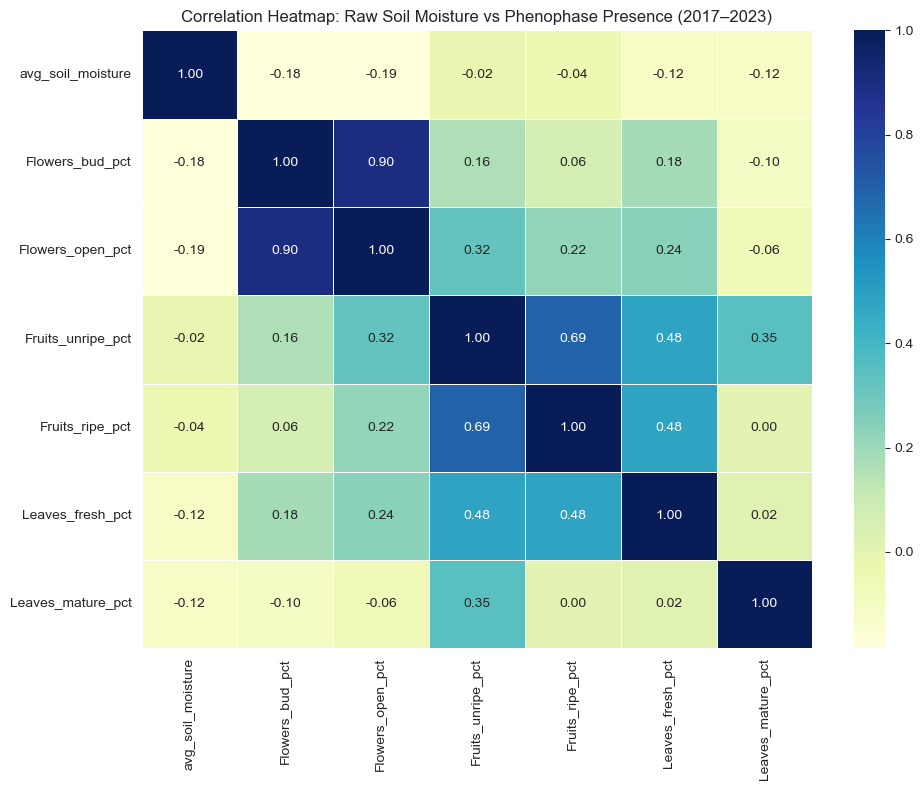

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the summary file
df = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/mango_phenophase_soilmoisture_summary.csv")

# Filter for 2017–2023
df = df[(df['year'] >= 2017) & (df['year'] <= 2023)].copy()

# Select relevant columns
phenophase_cols = [col for col in df.columns if col.endswith('_pct')]
cols = ['avg_soil_moisture'] + phenophase_cols

# Compute correlation matrix on raw values
raw_corr = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(raw_corr, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Raw Soil Moisture vs Phenophase Presence (2017–2023)")
plt.tight_layout()
plt.show()


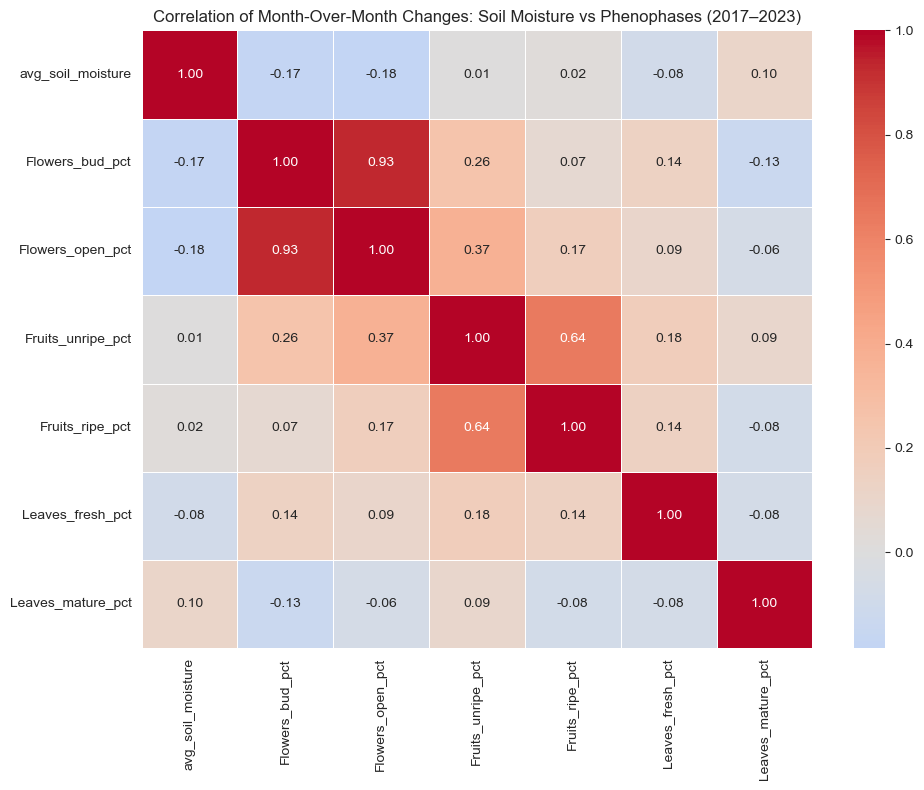

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/mango_phenophase_soilmoisture_summary.csv")


# Filter for 2017–2023 and sort
df = df[(df['year'] >= 2017) & (df['year'] <= 2023)].sort_values(by=['year', 'month']).reset_index(drop=True)

# Select relevant columns
columns = ['avg_soil_moisture'] + [col for col in df.columns if col.endswith('_pct')]
df_subset = df[columns].copy()

# Calculate month-over-month differences
df_diff = df_subset.diff().dropna()

# Compute correlation matrix of the changes
corr_change = df_diff.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_change, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation of Month-Over-Month Changes: Soil Moisture vs Phenophases (2017–2023)")
plt.tight_layout()
plt.show()


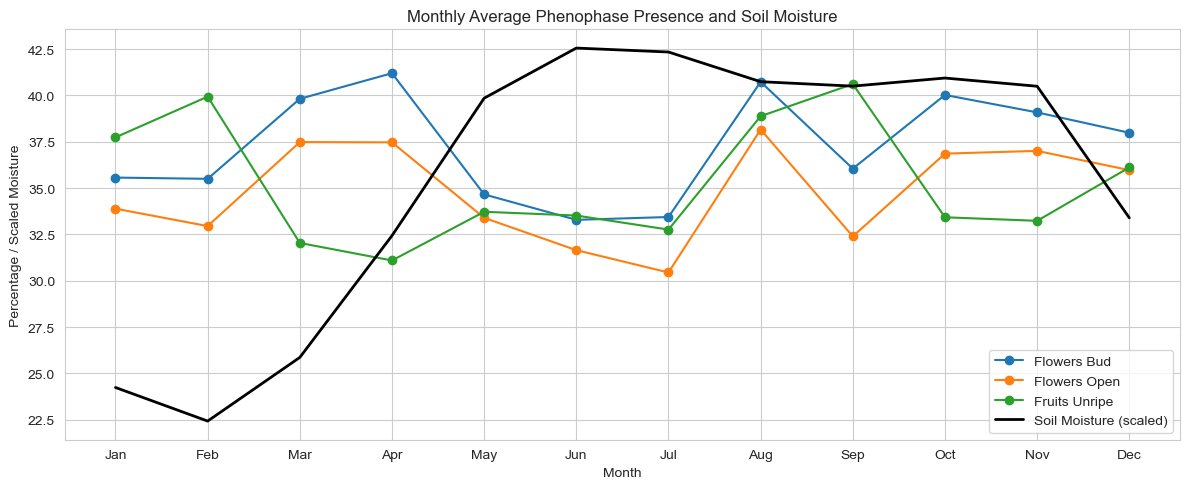

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mango_phenophase_soilmoisture_summary.csv")
monthly_avg = df.groupby('month').mean(numeric_only=True).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_avg['month'], monthly_avg['Flowers_bud_pct'] * 100, label='Flowers Bud', marker='o')
plt.plot(monthly_avg['month'], monthly_avg['Flowers_open_pct'] * 100, label='Flowers Open', marker='o')
plt.plot(monthly_avg['month'], monthly_avg['Fruits_unripe_pct'] * 100, label='Fruits Unripe', marker='o')
plt.plot(monthly_avg['month'], monthly_avg['avg_soil_moisture'] * 100, label='Soil Moisture (scaled)', color='black', linewidth=2)

plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title("Monthly Average Phenophase Presence and Soil Moisture")
plt.xlabel("Month")
plt.ylabel("Percentage / Scaled Moisture")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


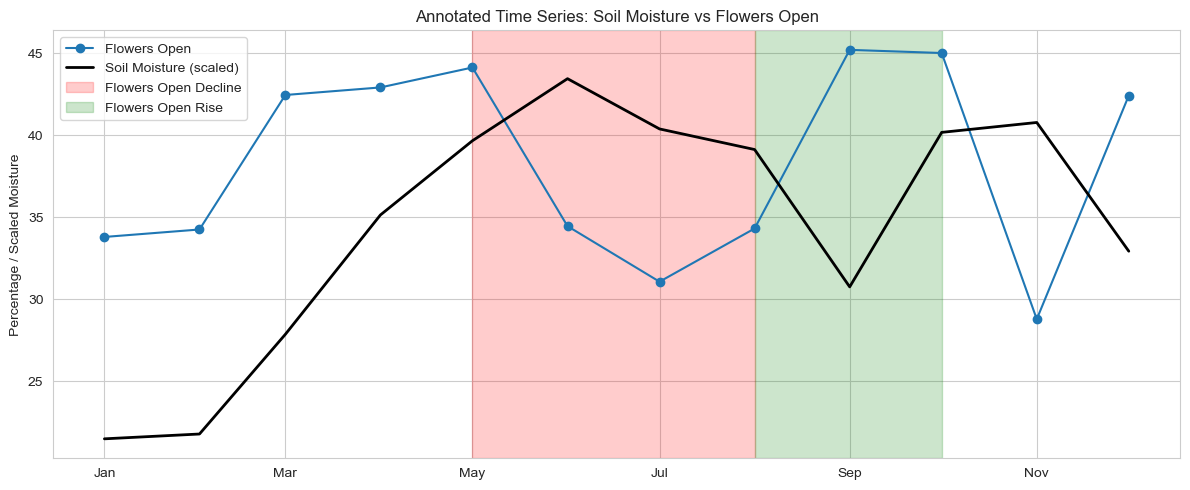

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load and prepare data
df = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/mango_phenophase_soilmoisture_summary.csv")
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
year_df = df[df['year'] == 2018]

# Plot Flowers Open vs Soil Moisture (scaled)
plt.figure(figsize=(12, 5))
plt.plot(year_df['date'], year_df['Flowers_open_pct'] * 100, label='Flowers Open', marker='o', color='tab:blue')
plt.plot(year_df['date'], year_df['avg_soil_moisture'] * 100, label='Soil Moisture (scaled)', color='black', linewidth=2)

# Annotated vertical bands
plt.axvspan(pd.to_datetime("2018-05-01"), pd.to_datetime("2018-08-01"), color='red', alpha=0.2, label='Flowers Open Decline')
plt.axvspan(pd.to_datetime("2018-08-01"), pd.to_datetime("2018-10-01"), color='green', alpha=0.2, label='Flowers Open Rise')

# Format x-axis to show only month names
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Final touches
plt.title("Annotated Time Series: Soil Moisture vs Flowers Open")
plt.ylabel("Percentage / Scaled Moisture")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


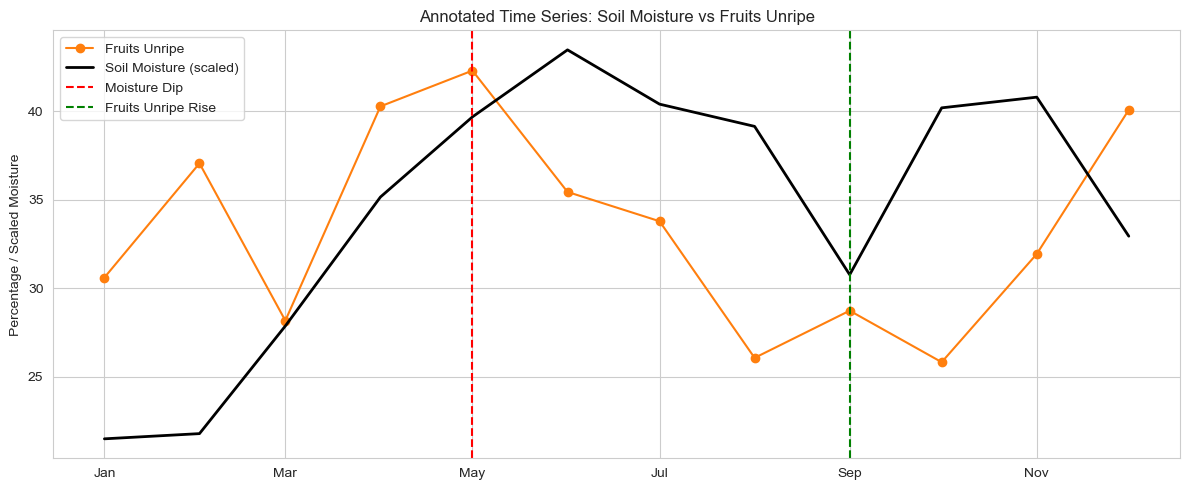

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load data
df = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/mango_phenophase_soilmoisture_summary.csv")
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
year_df = df[df['year'] == 2018]

# Plot Fruits Unripe vs Soil Moisture
plt.figure(figsize=(12, 5))
plt.plot(year_df['date'], year_df['Fruits_unripe_pct'] * 100, label='Fruits Unripe', marker='o', color='tab:orange')
plt.plot(year_df['date'], year_df['avg_soil_moisture'] * 100, label='Soil Moisture (scaled)', color='black', linewidth=2)

# Annotated vertical lines
plt.axvline(pd.to_datetime("2018-05-01"), color='red', linestyle='--', label='Moisture Dip')
plt.axvline(pd.to_datetime("2018-09-01"), color='green', linestyle='--', label='Fruits Unripe Rise')

# Format x-axis to show only month names
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Final touches
plt.title("Annotated Time Series: Soil Moisture vs Fruits Unripe")
plt.ylabel("Percentage / Scaled Moisture")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


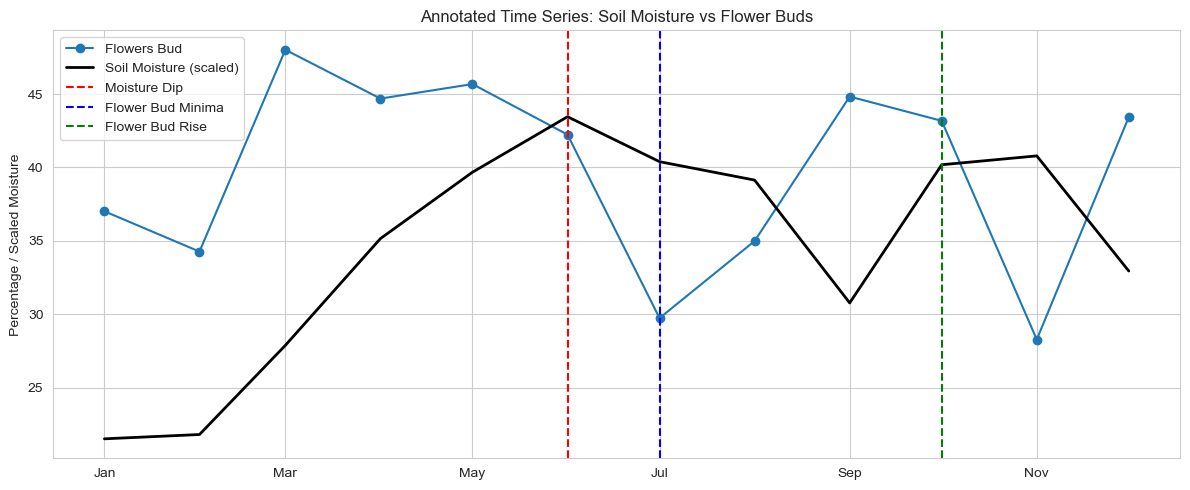

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load and prepare data
df = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/mango_phenophase_soilmoisture_summary.csv")
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
year_df = df[df['year'] == 2018]

# Plot Flower Bud vs Soil Moisture
plt.figure(figsize=(12, 5))
plt.plot(year_df['date'], year_df['Flowers_bud_pct'] * 100, label='Flowers Bud', marker='o')
plt.plot(year_df['date'], year_df['avg_soil_moisture'] * 100, label='Soil Moisture (scaled)', color='black', linewidth=2)

# Annotated vertical lines
plt.axvline(pd.to_datetime("2018-06-01"), color='red', linestyle='--', label='Moisture Dip')
plt.axvline(pd.to_datetime("2018-07-01"), color='blue', linestyle='--', label='Flower Bud Minima')
plt.axvline(pd.to_datetime("2018-10-01"), color='green', linestyle='--', label='Flower Bud Rise')

# Format x-axis to show only month names
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Final touches
plt.title("Annotated Time Series: Soil Moisture vs Flower Buds")
plt.ylabel("Percentage / Scaled Moisture")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


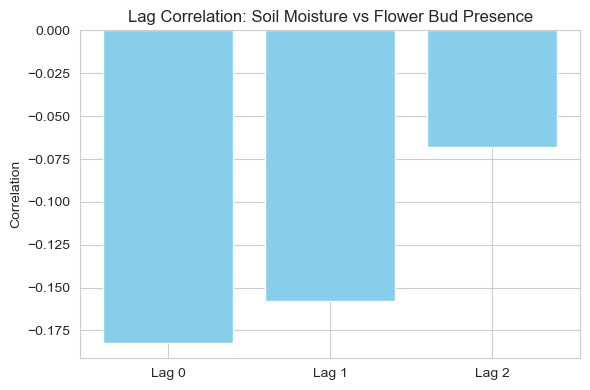

In [ ]:
df = pd.read_csv("../../../data/spring_2025_data/soil_moisture_data/mango_phenophase_soilmoisture_summary.csv")
df = df.sort_values(by=['year', 'month']).reset_index(drop=True)

lags = [0, 1, 2]
corrs = []

for lag in lags:
    shifted = df['avg_soil_moisture'].shift(lag)
    corr = df['Flowers_bud_pct'].corr(shifted)
    corrs.append(corr)

plt.figure(figsize=(6, 4))
plt.bar([f"Lag {i}" for i in lags], corrs, color='skyblue')
plt.title("Lag Correlation: Soil Moisture vs Flower Bud Presence")
plt.ylabel("Correlation")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


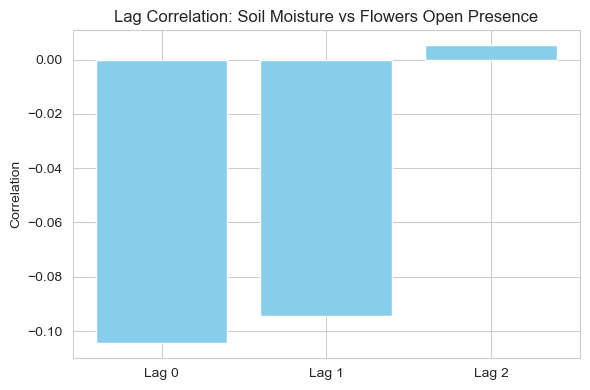

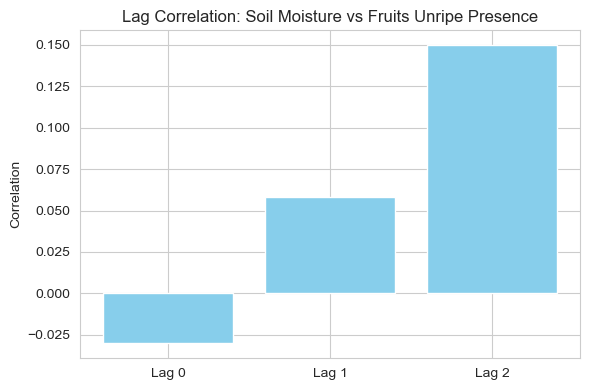

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and sort data
df = pd.read_csv("mango_phenophase_soilmoisture_summary.csv")
df = df.sort_values(by=['year', 'month']).reset_index(drop=True)

# Define phenophases to check
phenos = ['Flowers_open_pct', 'Fruits_unripe_pct']
titles = ['Flowers Open', 'Fruits Unripe']
lags = [0, 1, 2]

# Generate lag correlation bar charts
for pheno, title in zip(phenos, titles):
    corrs = []
    for lag in lags:
        shifted = df['avg_soil_moisture'].shift(lag)
        corr = df[pheno].corr(shifted)
        corrs.append(corr)

    plt.figure(figsize=(6, 4))
    plt.bar([f"Lag {i}" for i in lags], corrs, color='skyblue')
    plt.title(f"Lag Correlation: Soil Moisture vs {title} Presence")
    plt.ylabel("Correlation")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
